# 01 — Exploratory Data Analysis
## Valencia Airbnb Investment Intelligence

**Pregunta central:** ¿Qué factores determinan el precio y la rentabilidad en el mercado Airbnb de Valencia?

**Research questions que responde este notebook:**
- RQ1: ¿Cómo se distribuye el precio en Valencia y qué lo determina?
- RQ2: ¿Qué barrios tienen mayor rentabilidad?
- RQ5: ¿Qué características tienen los listings más rentables?

**Análisis cubierto:**
1. Carga y limpieza de datos
2. Análisis univariable (precio, ocupación, ingresos)
3. Análisis bivariable (precio vs. features)
4. Análisis multivariable (correlaciones)
5. Análisis por barrio
6. Conclusiones del EDA

---

## 0. Setup e Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
import sys
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Add project root to path ──────────────────────────────────
from pathlib import Path
PROJECT_ROOT = Path(r'C:\Users\User\Desktop\GitHub\PROYECTO FINAL FINAL\airbnb_valencia')
sys.path.insert(0, str(PROJECT_ROOT))
from config.config import (
    FILES, PROCESSED, REPORTS, ZONE_MAP, SCORE_COLS,
    PRICE_MIN, PRICE_MAX, ALPHA,
    COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT,
    COLOR_GOOD, COLOR_WARN, COLOR_BAD,
    FIG_DPI, FIG_SIZE_WIDE, FIG_SIZE_SQ
)
from src.data_loader import load_listings, load_reviews
from src.cleaning import run_full_pipeline, clean_price

# ── Style ─────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = [COLOR_PRIMARY, COLOR_ACCENT, COLOR_SECONDARY,
           COLOR_GOOD, COLOR_WARN, COLOR_BAD]
sns.set_palette(PALETTE)

def save_fig(name):
    """Save figure to reports/figures/."""
    os.makedirs(REPORTS, exist_ok=True)
    plt.savefig(REPORTS / name, dpi=FIG_DPI, bbox_inches='tight')
    print(f'💾 {name}')

print('✅ Setup complete')

✅ Setup complete


## 1. Carga y Limpieza de Datos

In [6]:
# ── Load raw data ─────────────────────────────────────────────
df_raw      = load_listings(FILES['listings'])
df_rev_raw  = load_reviews(FILES['reviews'])

print(f'\nRaw listings: {df_raw.shape}')
print(f'Raw reviews:  {df_rev_raw.shape}')
display(df_raw.head(3))

✅ listings.csv loaded — 7,844 rows × 79 cols
✅ reviews.csv loaded — 405,030 rows × 6 cols
   Period: 2010-10-12 → 2025-09-23

Raw listings: (7844, 79)
Raw reviews:  (405030, 6)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,48154,https://www.airbnb.com/rooms/48154,20250923203019,2025-09-24,city scrape,Precioso apartamento con wifi,Second floor on a farm from the late 19th cent...,Very close neighborhood to the city's old town...,https://a0.muscache.com/pictures/1109085/9c0d4...,219476,https://www.airbnb.com/users/show/219476,Antonio,2010-09-01,Spain,Un saludo a todos. Espero que os pongáis en co...,within a few hours,100%,96%,f,https://a0.muscache.com/im/users/219476/profil...,https://a0.muscache.com/im/users/219476/profil...,La Saïdia,4.00,4.00,"['email', 'phone']",t,t,"Valencia, Spain",MORVEDRE,LA SAIDIA,39.48,-0.38,Entire rental unit,Entire home/apt,4,1.00,1 bath,2.00,2.00,"[""TV"", ""Host greets you"", ""Essentials"", ""Washe...",$83.00,3,25,2.00,4.00,10.00,25.00,3.00,23.50,NaN,t,10,34,60,150,2025-09-24,197,26,1,69,30,156,12948.00,2010-10-12,2025-09-15,4.61,4.68,4.63,4.85,4.80,4.52,4.52,VT-41540-V,f,4,4,0,0,1.08
1,137143,https://www.airbnb.com/rooms/137143,20250923203019,2025-09-24,city scrape,PENTHOUSE ON FRONT LINE BEACH,NaN,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,670775,https://www.airbnb.com/users/show/670775,Maria De La Piedad,2011-06-06,"Valencia, Spain",Hola a todos! Mi nombre es Piedad Villena y es...,within a few hours,100%,100%,f,https://a0.muscache.com/im/pictures/user/26792...,https://a0.muscache.com/im/pictures/user/26792...,Camins al Grau,5.00,5.00,"['email', 'phone']",t,t,NaN,EL SALER,POBLATS DEL SUD,39.36,-0.32,Entire rental unit,Entire home/apt,7,1.50,1.5 baths,1.00,14.00,"[""TV"", ""Wifi"", ""Pool"", ""Elevator"", ""Washer"", ""...",$390.00,10,170,10.00,10.00,170.00,170.00,10.00,170.00,NaN,t,4,16,20,20,2025-09-24,1,0,0,20,0,0,0.00,2013-07-02,2013-07-02,0.00,5.00,5.00,5.00,5.00,4.00,4.00,VT32745V,f,5,5,0,0,0.01
2,149715,https://www.airbnb.com/rooms/149715,20250923203019,2025-09-24,city scrape,1900 Style Valencian Beach Home for 10px,Typical town house with 5 bedrooms and 4 bathr...,"Surrounded by historic houses, authentic res...",https://a0.muscache.com/pictures/808b4883-c57f...,5947,https://www.airbnb.com/users/show/5947,Susana Barbara,2009-01-03,"Valencia, Spain",I’ve been traveling since I was 15. I moved ...,within an hour,100%,98%,f,https://a0.muscache.com/im/pictures/user/User-...,https://a0.muscache.com/im/pictures/user/User-...,Poblados Marítimos,1.00,1.00,['phone'],t,t,"Valencia, Valencian Community, Spain",CABANYAL-CANYAMELAR,POBLATS MARITIMS,39.47,-0.33,Entire home,Entire home/apt,10,4.00,4 baths,5.00,7.00,"[""Hot water kettle"", ""Private patio or balcony...",$245.00,2,9,1.00,3.00,9.00,9.00,2.10,9.00,NaN,t,9,27,

In [7]:
# ── Data quality overview BEFORE cleaning ─────────────────────
print('=== NULL VALUES (%) ===')
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
print(null_pct[null_pct > 0].to_string())

print(f'\n=== DUPLICATES ===')
print(f'Duplicate rows: {df_raw.duplicated().sum()}')
print(f'Duplicate IDs:  {df_raw["id"].duplicated().sum()}')

=== NULL VALUES (%) ===
calendar_updated              100.00
host_neighbourhood             77.77
neighbourhood                  58.22
neighborhood_overview          58.22
host_about                     46.24
license                        42.21
host_location                  27.50
review_scores_accuracy         12.47
review_scores_value            12.47
review_scores_checkin          12.47
review_scores_communication    12.47
review_scores_location         12.47
first_review                   12.46
last_review                    12.46
review_scores_rating           12.46
review_scores_cleanliness      12.46
reviews_per_month              12.46
bathrooms                      11.07
beds                           11.07
estimated_revenue_l365d        11.03
price                          11.03
host_response_time              6.45
host_response_rate              6.45
host_is_superhost               4.97
host_acceptance_rate            4.12
bedrooms                        3.98
description   

In [9]:
# ── Run full cleaning pipeline ────────────────────────────────
from src.data_loader import load_calendar

PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_PATH.mkdir(exist_ok=True)

df_cal_raw = load_calendar(FILES['calendar'])
df, df_cal, df_rev = run_full_pipeline(df_raw, df_cal_raw, df_rev_raw, ZONE_MAP)

print(f'\n✅ Clean datasets ready:')
print(f'  listings: {df.shape}')
print(f'  calendar: {df_cal.shape}')
print(f'  reviews:  {df_rev.shape}')

# Save processed data
df.to_csv(PROCESSED_PATH / 'listings_clean.csv', index=False)
df_rev.to_csv(PROCESSED_PATH / 'reviews_clean.csv', index=False)
print('\n💾 listings_clean.csv saved')
print('💾 reviews_clean.csv saved')

✅ calendar.csv loaded — 2,863,060 rows × 7 cols
   Period: 2025-09-23 → 2026-09-23

🔧 CLEANING LISTINGS ───────────────────────────────────
  dropped 12 irrelevant columns
  boolean columns converted: ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable']
  percentage columns fixed: ['host_response_rate', 'host_acceptance_rate']
  date columns parsed: ['host_since', 'first_review', 'last_review']
  price_eur: 64 outliers removed (< 10€ or > 1000€)
  price imputed: 865 nulls → 0 remaining
  review_scores_rating: 939 nulls imputed
  review_scores_accuracy: 940 nulls imputed
  review_scores_cleanliness: 939 nulls imputed
  review_scores_checkin: 940 nulls imputed
  review_scores_communication: 940 nulls imputed
  review_scores_location: 940 nulls imputed
  review_scores_value: 940 nulls imputed
  host_segment added: {'Profesional': 2893, 'Semi-pro': 2559, 'Amateur': 2328}
  zone added: {'CENTRE': 2601, 'SEAFRONT': 2175, 'SOUTH': 1429, 'NORTH': 637, 'EA

---
## 2. Análisis Univariable
### 2.1 Distribución del Precio

=== PRICE STATISTICS (€/night) ===
count   7780.00
mean     112.62
std       76.67
min       11.00
25%       68.00
50%      103.00
75%      132.00
max     1000.00

Skewness: 3.56
Kurtosis: 24.59
💾 01_price_distribution.png


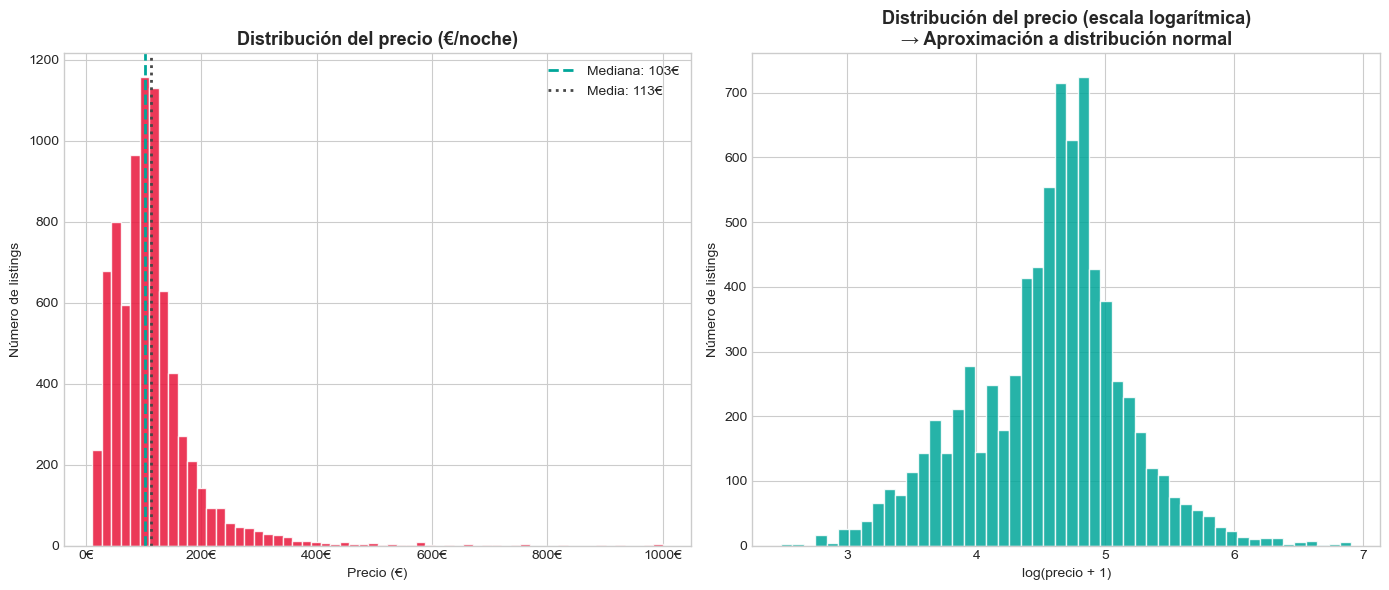


💡 INSIGHT: El precio tiene distribución fuertemente sesgada a la derecha
   → Se usará log(precio) en los análisis estadísticos


In [10]:
# ── Price distribution ────────────────────────────────────────
print('=== PRICE STATISTICS (€/night) ===')
print(df['price_eur'].describe().to_string())
print(f'\nSkewness: {df["price_eur"].skew():.2f}')
print(f'Kurtosis: {df["price_eur"].kurtosis():.2f}')

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE_WIDE)

# Raw price histogram
axes[0].hist(df['price_eur'].dropna(), bins=60,
             color=COLOR_PRIMARY, edgecolor='white', alpha=0.85)
axes[0].axvline(df['price_eur'].median(), color=COLOR_ACCENT,
                linewidth=2, linestyle='--',
                label=f'Mediana: {df["price_eur"].median():.0f}€')
axes[0].axvline(df['price_eur'].mean(), color=COLOR_SECONDARY,
                linewidth=2, linestyle=':',
                label=f'Media: {df["price_eur"].mean():.0f}€')
axes[0].set_title('Distribución del precio (€/noche)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Precio (€)')
axes[0].set_ylabel('Número de listings')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}€'))

# Log-transformed price
df['log_price'] = np.log1p(df['price_eur'])
axes[1].hist(df['log_price'].dropna(), bins=50,
             color=COLOR_ACCENT, edgecolor='white', alpha=0.85)
axes[1].set_title('Distribución del precio (escala logarítmica)\n→ Aproximación a distribución normal',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(precio + 1)')
axes[1].set_ylabel('Número de listings')

plt.tight_layout()
save_fig('01_price_distribution.png')
plt.show()

print('\n💡 INSIGHT: El precio tiene distribución fuertemente sesgada a la derecha')
print('   → Se usará log(precio) en los análisis estadísticos')

In [11]:
# ── Normality test on price ───────────────────────────────────
from src.analysis import test_normality

print('=== NORMALITY TESTS ===')
res_raw = test_normality(df['price_eur'], name='price_eur')
res_log = test_normality(df['log_price'], name='log_price')

print('\n💡 INSIGHT: Log-transformation justifies use of non-parametric tests')
print('   for price analysis (Spearman correlation, Mann-Whitney, Kruskal-Wallis)')

=== NORMALITY TESTS ===
  Normality (price_eur) — D'Agostino-Pearson: stat=6179.5073, p=0.0000 → NOT NORMAL ⚠️ (α=0.05)
  Normality (log_price) — D'Agostino-Pearson: stat=108.9594, p=0.0000 → NOT NORMAL ⚠️ (α=0.05)

💡 INSIGHT: Log-transformation justifies use of non-parametric tests
   for price analysis (Spearman correlation, Mann-Whitney, Kruskal-Wallis)


In [ ]:
# ── Revenue & Occupancy distributions ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE_WIDE)

# Estimated revenue
rev_data = df['estimated_revenue_l365d'].dropna()
rev_data = rev_data[rev_data > 0]
axes[0].hist(rev_data, bins=50, color=COLOR_PRIMARY, edgecolor='white', alpha=0.85)
axes[0].axvline(rev_data.median(), color=COLOR_ACCENT, linewidth=2, linestyle='--',
                label=f'Mediana: {rev_data.median():,.0f}€')
axes[0].set_title('Ingresos estimados anuales por listing\n(estimated_revenue_l365d)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Ingresos estimados (€/año)')
axes[0].set_ylabel('Número de listings')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}€'))

# Occupancy
occ_data = df['estimated_occupancy_l365d']
axes[1].hist(occ_data, bins=40, color=COLOR_ACCENT, edgecolor='white', alpha=0.85)
axes[1].axvline(occ_data.median(), color=COLOR_PRIMARY, linewidth=2, linestyle='--',
                label=f'Mediana: {occ_data.median():.0f} noches')
axes[1].set_title('Noches ocupadas estimadas (último año)\n(estimated_occupancy_l365d)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Noches ocupadas')
axes[1].set_ylabel('Número de listings')
axes[1].legend()

plt.tight_layout()
save_fig('02_revenue_occupancy.png')
plt.show()

print('=== REVENUE STATISTICS ===')
print(rev_data.describe().to_string())
print('\n=== OCCUPANCY STATISTICS ===')
print(occ_data.describe().to_string())

💾 03_room_type.png


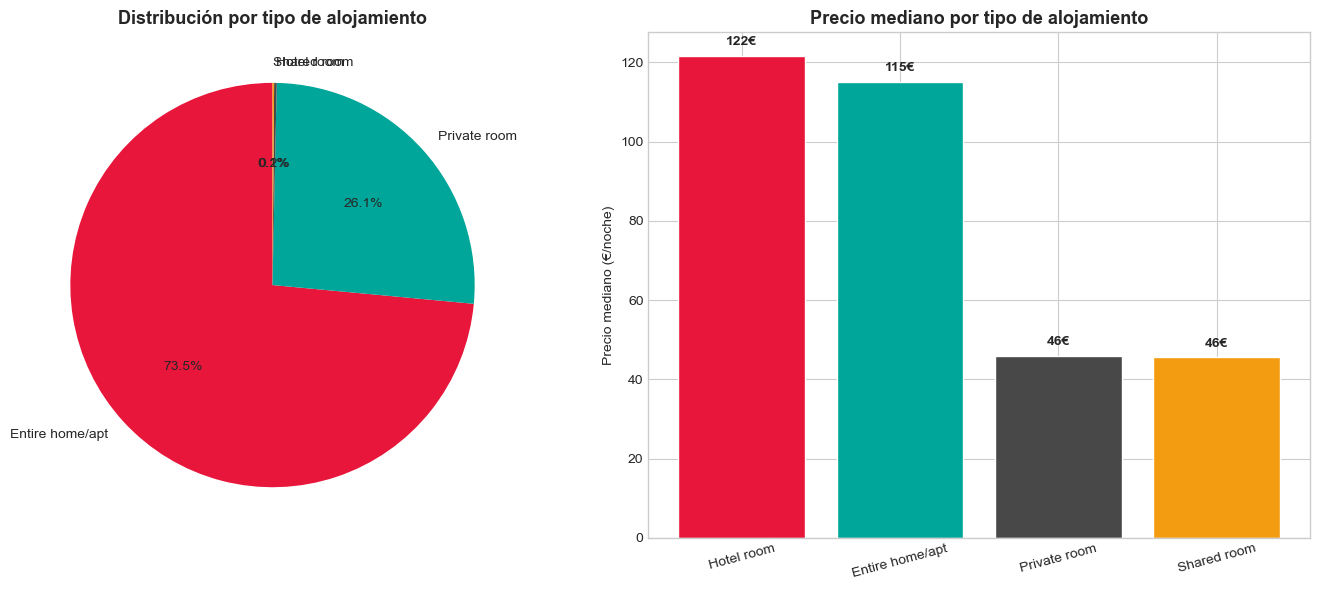


Precio mediano por tipo:
room_type
Hotel room        121.50
Entire home/apt   115.00
Private room       46.00
Shared room        45.50


In [12]:
# ── Room type distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE_WIDE)

room_counts = df['room_type'].value_counts()
colors_rt   = [COLOR_PRIMARY, COLOR_ACCENT, COLOR_SECONDARY, COLOR_WARN]

# Count
axes[0].pie(room_counts, labels=room_counts.index,
            autopct='%1.1f%%', colors=colors_rt, startangle=90)
axes[0].set_title('Distribución por tipo de alojamiento', fontsize=13, fontweight='bold')

# Median price per room type
price_by_room = df.groupby('room_type')['price_eur'].median().sort_values(ascending=False)
bars = axes[1].bar(price_by_room.index, price_by_room.values,
                   color=colors_rt, edgecolor='white')
for bar, val in zip(bars, price_by_room.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val:.0f}€', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Precio mediano por tipo de alojamiento', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Precio mediano (€/noche)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
save_fig('03_room_type.png')
plt.show()

print('\nPrecio mediano por tipo:')
print(price_by_room.to_string())

---
## 3. Análisis Bivariable
### 3.1 Precio vs. Variables Numéricas

💾 04_price_bivariate.png


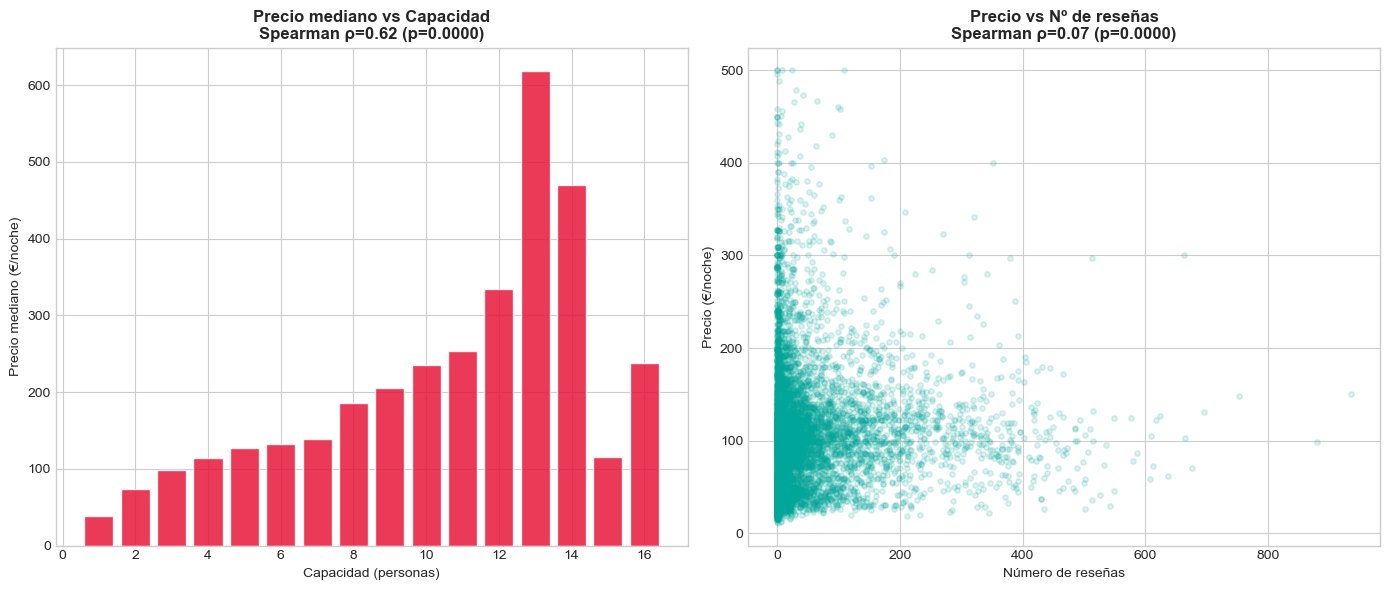

In [13]:
# ── Price vs accommodates, bedrooms ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE_WIDE)

# Price vs accommodates
acc_price = df.groupby('accommodates')['price_eur'].median()
axes[0].bar(acc_price.index, acc_price.values,
            color=COLOR_PRIMARY, edgecolor='white', alpha=0.85)
rho1, p1 = stats.spearmanr(df['accommodates'], df['price_eur'].fillna(df['price_eur'].median()))
axes[0].set_title(f'Precio mediano vs Capacidad\nSpearman ρ={rho1:.2f} (p={p1:.4f})',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Capacidad (personas)')
axes[0].set_ylabel('Precio mediano (€/noche)')

# Price vs reviews_per_month
df_plot = df[['price_eur','number_of_reviews']].dropna()
df_plot = df_plot[df_plot['price_eur'] <= 500]
axes[1].scatter(df_plot['number_of_reviews'], df_plot['price_eur'],
                alpha=0.15, color=COLOR_ACCENT, s=15)
rho2, p2 = stats.spearmanr(df_plot['number_of_reviews'], df_plot['price_eur'])
axes[1].set_title(f'Precio vs Nº de reseñas\nSpearman ρ={rho2:.2f} (p={p2:.4f})',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de reseñas')
axes[1].set_ylabel('Precio (€/noche)')

plt.tight_layout()
save_fig('04_price_bivariate.png')
plt.show()

💾 05_price_vs_rating.png


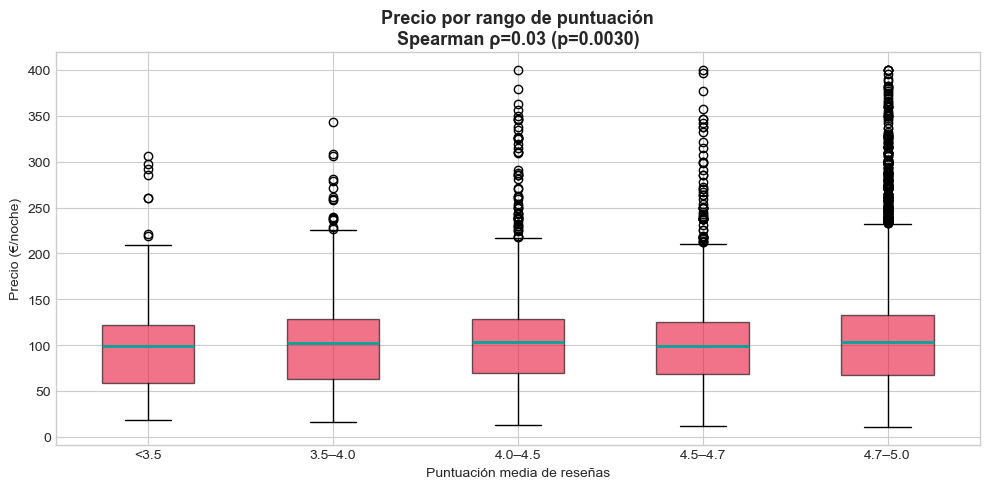

In [14]:
# ── Price vs Review Score ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

data = df[['price_eur','review_scores_rating']].dropna()
data = data[data['price_eur'] <= 400]

# Bin by rating
data['rating_bin'] = pd.cut(data['review_scores_rating'],
                             bins=[0, 3.5, 4.0, 4.5, 4.7, 5.01],
                             labels=['<3.5', '3.5–4.0', '4.0–4.5', '4.5–4.7', '4.7–5.0'])
bp = data.groupby('rating_bin')['price_eur'].apply(list)
ax.boxplot(bp.values, labels=bp.index,
           patch_artist=True,
           boxprops=dict(facecolor=COLOR_PRIMARY, alpha=0.6),
           medianprops=dict(color=COLOR_ACCENT, linewidth=2))

rho, p = stats.spearmanr(data['review_scores_rating'], data['price_eur'])
ax.set_title(f'Precio por rango de puntuación\nSpearman ρ={rho:.2f} (p={p:.4f})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Puntuación media de reseñas')
ax.set_ylabel('Precio (€/noche)')

plt.tight_layout()
save_fig('05_price_vs_rating.png')
plt.show()

### 3.2 Precio y Rentabilidad por Barrio

=== ESTADÍSTICAS POR BARRIO ===


,n_listings,median_price,median_revenue,median_occupancy,median_rating
neighbourhood_group_cleansed,,,,,
CIUTAT VELLA,1280,122.00,9900.00,66.00,4.75
L'EIXAMPLE,685,121.00,7920.00,66.00,4.78
CAMINS AL GRAU,714,97.00,6630.00,66.00,4.78
POBLATS MARITIMS,1461,106.00,6578.00,60.00,4.75
QUATRE CARRERES,808,98.00,6327.00,60.00,4.78
EXTRAMURS,636,110.00,5712.00,54.00,4.79
PATRAIX,176,92.00,5170.00,55.00,4.79
CAMPANAR,134,81.50,4644.00,63.00,4.81
EL PLA DEL REAL,155,100.00,4440.00,60.00,4.74


💾 06_neighbourhood_price_revenue.png


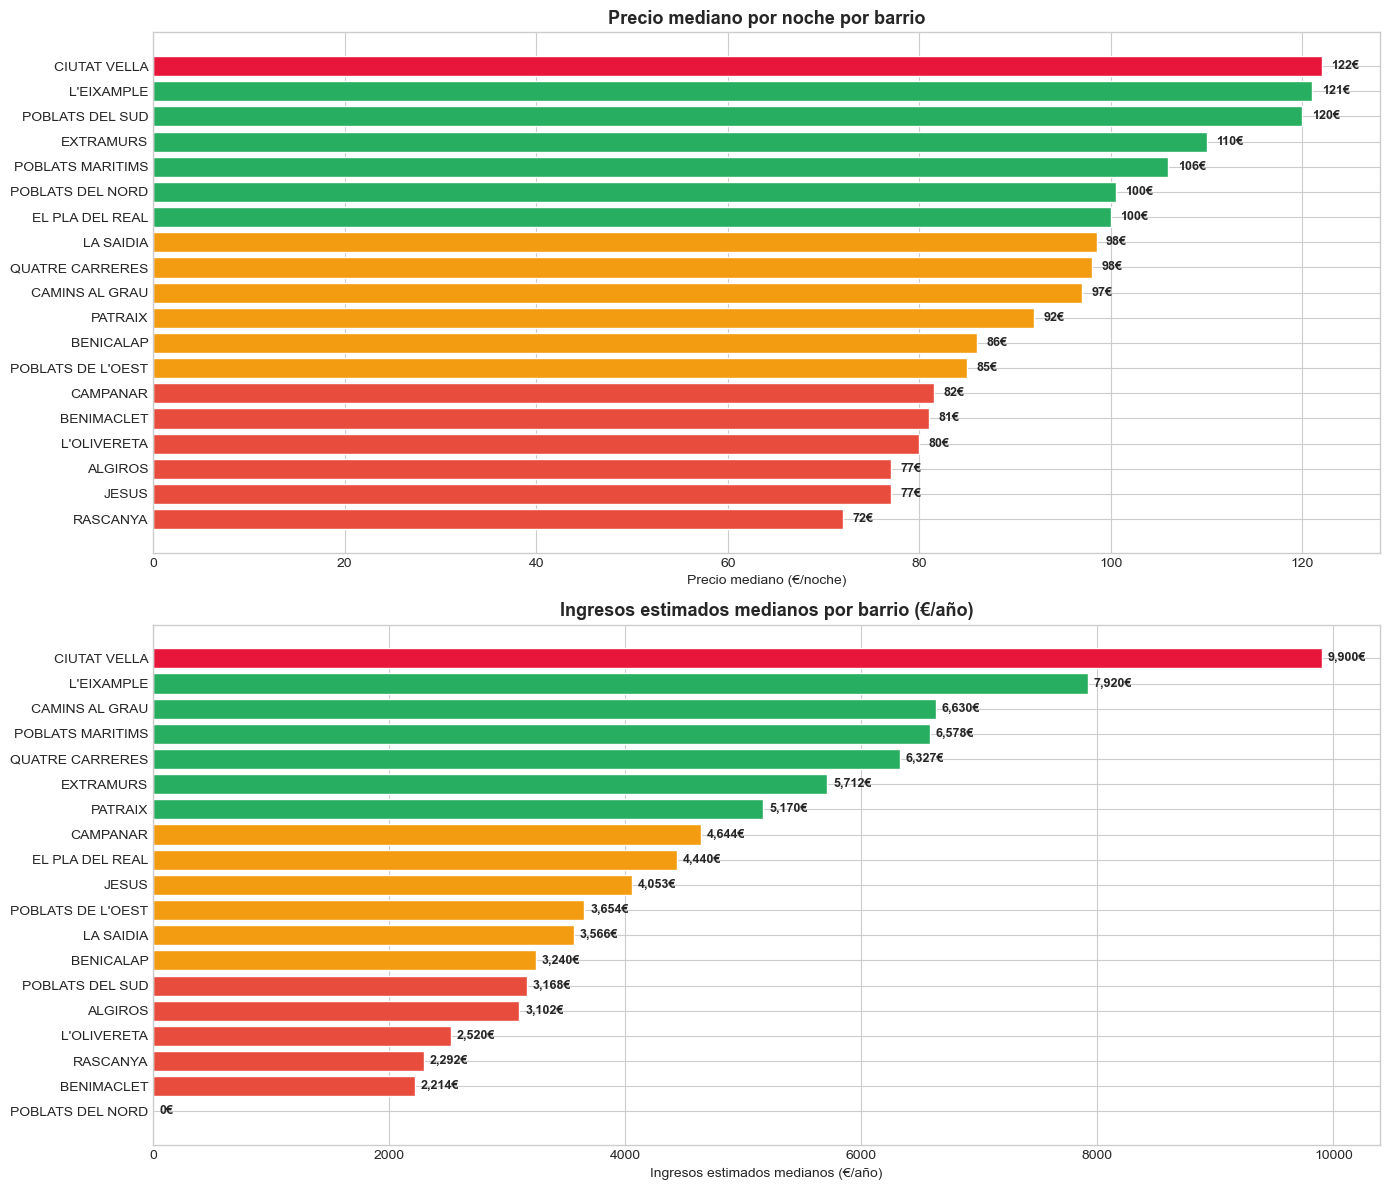


💡 INSIGHT: Precio alto ≠ rentabilidad alta.
   Ejemplo: POBLATS DEL SUD tiene precio alto pero pocos ingresos.


In [15]:
# ── Price by neighbourhood ────────────────────────────────────
hood_col = 'neighbourhood_group_cleansed'

hood_stats = df.groupby(hood_col).agg(
    n_listings          = ('id', 'count'),
    median_price        = ('price_eur', 'median'),
    median_revenue      = ('estimated_revenue_l365d', 'median'),
    median_occupancy    = ('estimated_occupancy_l365d', 'median'),
    median_rating       = ('review_scores_rating', 'median'),
).sort_values('median_revenue', ascending=False)

print('=== ESTADÍSTICAS POR BARRIO ===')
display(hood_stats)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Median price by neighbourhood
sorted_price = hood_stats['median_price'].sort_values(ascending=True)
colors_hood  = [COLOR_PRIMARY if v == sorted_price.max()
                else COLOR_GOOD if v >= sorted_price.quantile(0.66)
                else COLOR_WARN if v >= sorted_price.quantile(0.33)
                else COLOR_BAD
                for v in sorted_price.values]
bars = axes[0].barh(sorted_price.index, sorted_price.values,
                    color=colors_hood, edgecolor='white')
for bar, val in zip(bars, sorted_price.values):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}€', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Precio mediano por noche por barrio', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Precio mediano (€/noche)')

# Median revenue by neighbourhood
sorted_rev = hood_stats['median_revenue'].sort_values(ascending=True)
colors_rev = [COLOR_PRIMARY if v == sorted_rev.max()
              else COLOR_GOOD if v >= sorted_rev.quantile(0.66)
              else COLOR_WARN if v >= sorted_rev.quantile(0.33)
              else COLOR_BAD
              for v in sorted_rev.values]
bars2 = axes[1].barh(sorted_rev.index, sorted_rev.values,
                     color=colors_rev, edgecolor='white')
for bar, val in zip(bars2, sorted_rev.values):
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}€', va='center', fontsize=9, fontweight='bold')
axes[1].set_title('Ingresos estimados medianos por barrio (€/año)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Ingresos estimados medianos (€/año)')

plt.tight_layout()
save_fig('06_neighbourhood_price_revenue.png')
plt.show()

print('\n💡 INSIGHT: Precio alto ≠ rentabilidad alta.')
print('   Ejemplo: POBLATS DEL SUD tiene precio alto pero pocos ingresos.')

💾 07_price_vs_revenue_scatter.png


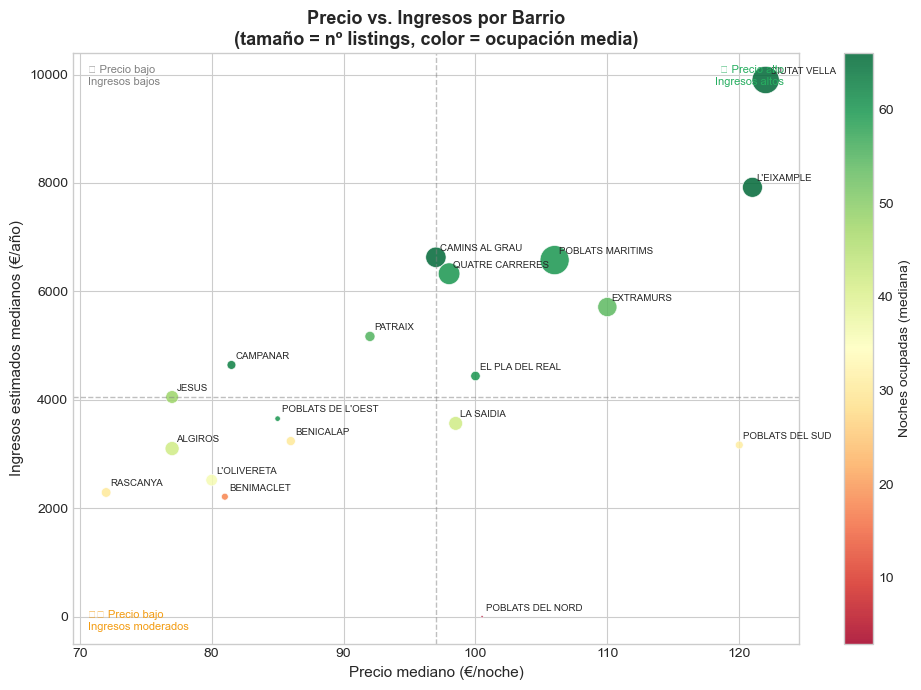

In [16]:
# ── Scatter: Price vs Revenue por barrio ─────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(hood_stats['median_price'],
                hood_stats['median_revenue'],
                s=hood_stats['n_listings'] * 0.3,
                c=hood_stats['median_occupancy'],
                cmap='RdYlGn', alpha=0.85, edgecolors='white', linewidth=0.5)

plt.colorbar(sc, ax=ax, label='Noches ocupadas (mediana)')

for hood, row in hood_stats.iterrows():
    ax.annotate(hood, (row['median_price'], row['median_revenue']),
                fontsize=7, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')

# Quadrant lines
ax.axvline(hood_stats['median_price'].median(), color='grey',
           linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(hood_stats['median_revenue'].median(), color='grey',
           linestyle='--', alpha=0.5, linewidth=1)

ax.set_xlabel('Precio mediano (€/noche)', fontsize=11)
ax.set_ylabel('Ingresos estimados medianos (€/año)', fontsize=11)
ax.set_title('Precio vs. Ingresos por Barrio\n'
             '(tamaño = nº listings, color = ocupación media)',
             fontsize=13, fontweight='bold')

# Quadrant labels
ax.text(0.02, 0.98, '🔴 Precio bajo\nIngresos bajos',
        transform=ax.transAxes, fontsize=8, va='top', color='gray')
ax.text(0.98, 0.98, '🌟 Precio alto\nIngresos altos',
        transform=ax.transAxes, fontsize=8, va='top', ha='right', color=COLOR_GOOD)
ax.text(0.02, 0.02, '⚠️ Precio bajo\nIngresos moderados',
        transform=ax.transAxes, fontsize=8, va='bottom', color=COLOR_WARN)

plt.tight_layout()
save_fig('07_price_vs_revenue_scatter.png')
plt.show()

---
## 4. Análisis Multivariable
### 4.1 Matriz de Correlación

✅ Spearman correlation matrix computed (6,869 rows, 10 variables)
💾 08_correlation_matrix.png


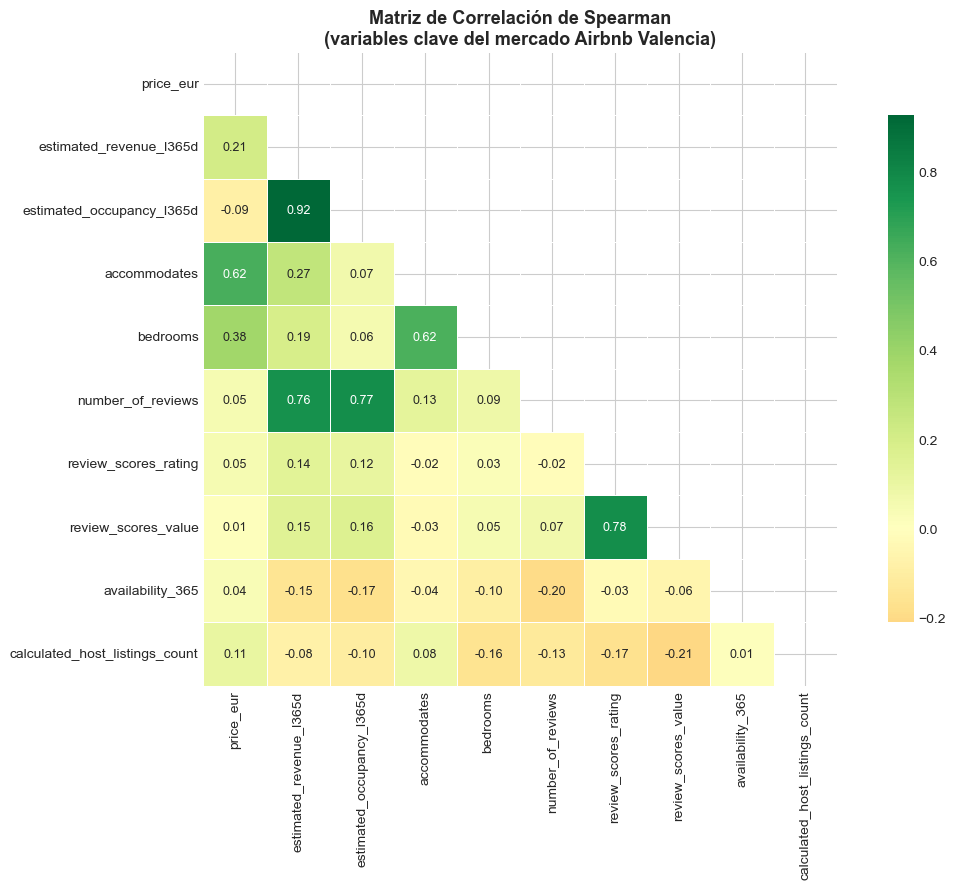


=== CORRELACIONES MÁS FUERTES CON PRECIO ===
price_eur                         1.00
accommodates                      0.62
bedrooms                          0.38
estimated_revenue_l365d           0.21
calculated_host_listings_count    0.11
estimated_occupancy_l365d        -0.09
review_scores_rating              0.05
number_of_reviews                 0.05
availability_365                  0.04
review_scores_value               0.01


In [17]:
# ── Spearman correlation matrix ───────────────────────────────
from src.analysis import correlation_matrix, price_drivers_summary

corr_cols = [
    'price_eur', 'estimated_revenue_l365d', 'estimated_occupancy_l365d',
    'accommodates', 'bedrooms', 'number_of_reviews',
    'review_scores_rating', 'review_scores_value',
    'availability_365', 'calculated_host_listings_count',
]

corr = correlation_matrix(df, corr_cols)

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
ax.set_title('Matriz de Correlación de Spearman\n(variables clave del mercado Airbnb Valencia)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('08_correlation_matrix.png')
plt.show()

print('\n=== CORRELACIONES MÁS FUERTES CON PRECIO ===')
print(corr['price_eur'].sort_values(key=abs, ascending=False).to_string())

=== PRINCIPALES DETERMINANTES DEL PRECIO ===
✅ Price drivers identified — top 5:
                                     feature  spearman_rho  p_value  significant
                                accommodates          0.62     0.00         True
calculated_host_listings_count_private_rooms         -0.52     0.00         True
                                        beds          0.50     0.00         True
 calculated_host_listings_count_entire_homes          0.41     0.00         True
                                    bedrooms          0.37     0.00         True
💾 09_price_drivers.png


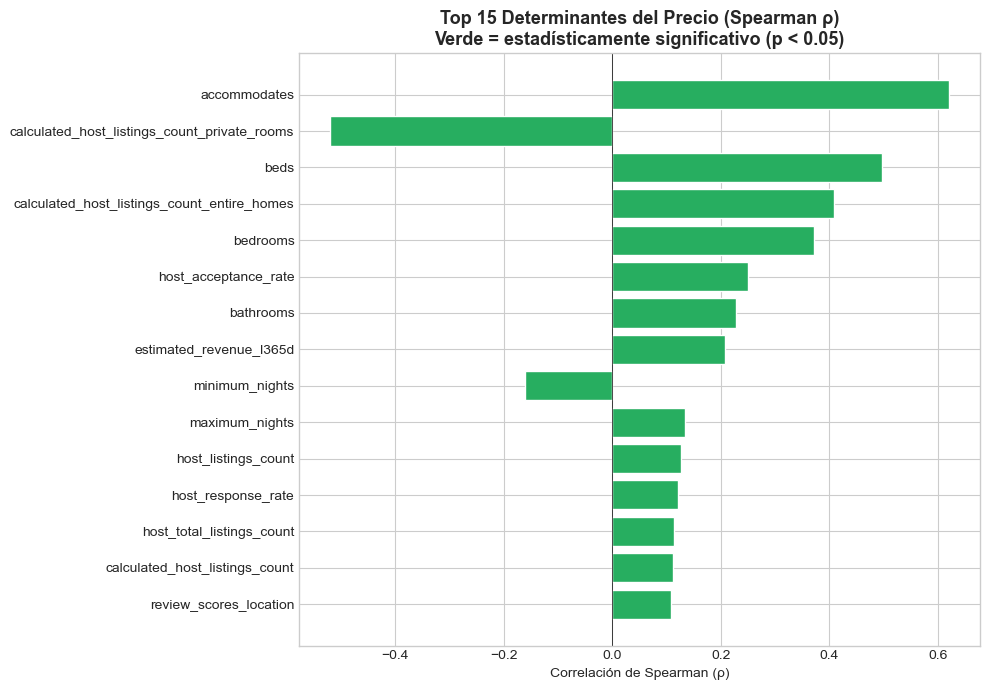

In [18]:
# ── Price drivers ranking ─────────────────────────────────────
print('=== PRINCIPALES DETERMINANTES DEL PRECIO ===')
drivers = price_drivers_summary(df)

# Plot top 15 drivers
top15 = drivers.head(15)
colors_sig = [COLOR_GOOD if s else COLOR_BAD for s in top15['significant']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15['feature'].iloc[::-1], top15['spearman_rho'].iloc[::-1],
               color=colors_sig[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Top 15 Determinantes del Precio (Spearman ρ)\n'
             'Verde = estadísticamente significativo (p < 0.05)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Correlación de Spearman (ρ)')

plt.tight_layout()
save_fig('09_price_drivers.png')
plt.show()

---
## 5. Análisis por Barrio — Rentabilidad
### 5.1 Precio vs. Ocupación vs. Ingresos

💾 10_neighbourhood_matrix.png


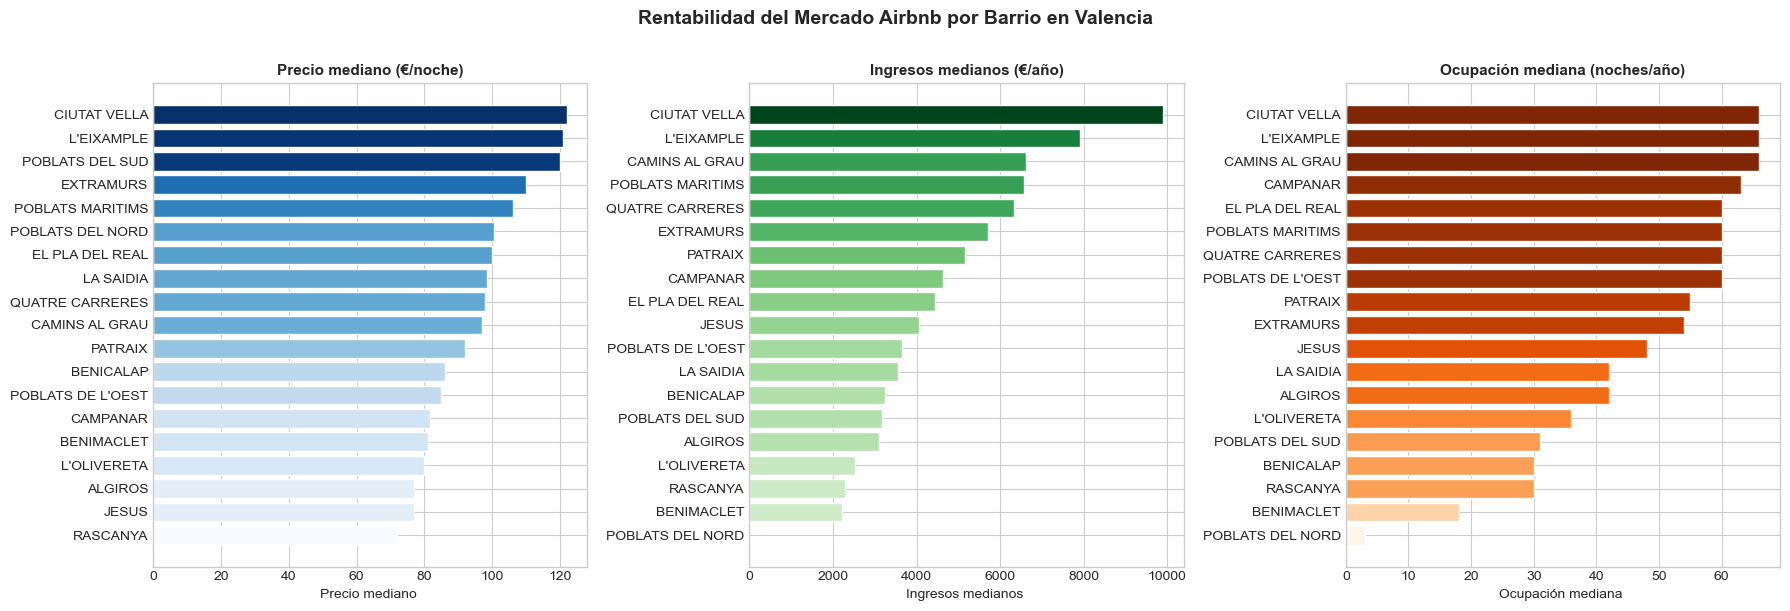

In [19]:
# ── Revenue vs Occupancy matrix ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = [
    ('median_price',     'Precio mediano (€/noche)',    'Blues'),
    ('median_revenue',   'Ingresos medianos (€/año)',   'Greens'),
    ('median_occupancy', 'Ocupación mediana (noches/año)', 'Oranges'),
]

for ax, (col, label, cmap) in zip(axes, metrics):
    sorted_df = hood_stats[col].sort_values(ascending=True)
    cmap_obj  = plt.cm.get_cmap(cmap)
    norm      = plt.Normalize(sorted_df.min(), sorted_df.max())
    colors    = [cmap_obj(norm(v)) for v in sorted_df.values]
    bars      = ax.barh(sorted_df.index, sorted_df.values,
                        color=colors, edgecolor='white')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel(label.split('(')[0])

plt.suptitle('Rentabilidad del Mercado Airbnb por Barrio en Valencia',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig('10_neighbourhood_matrix.png')
plt.show()

---
## 6. Evolución de la Demanda (Reviews como Proxy)

💾 11_demand_trend.png


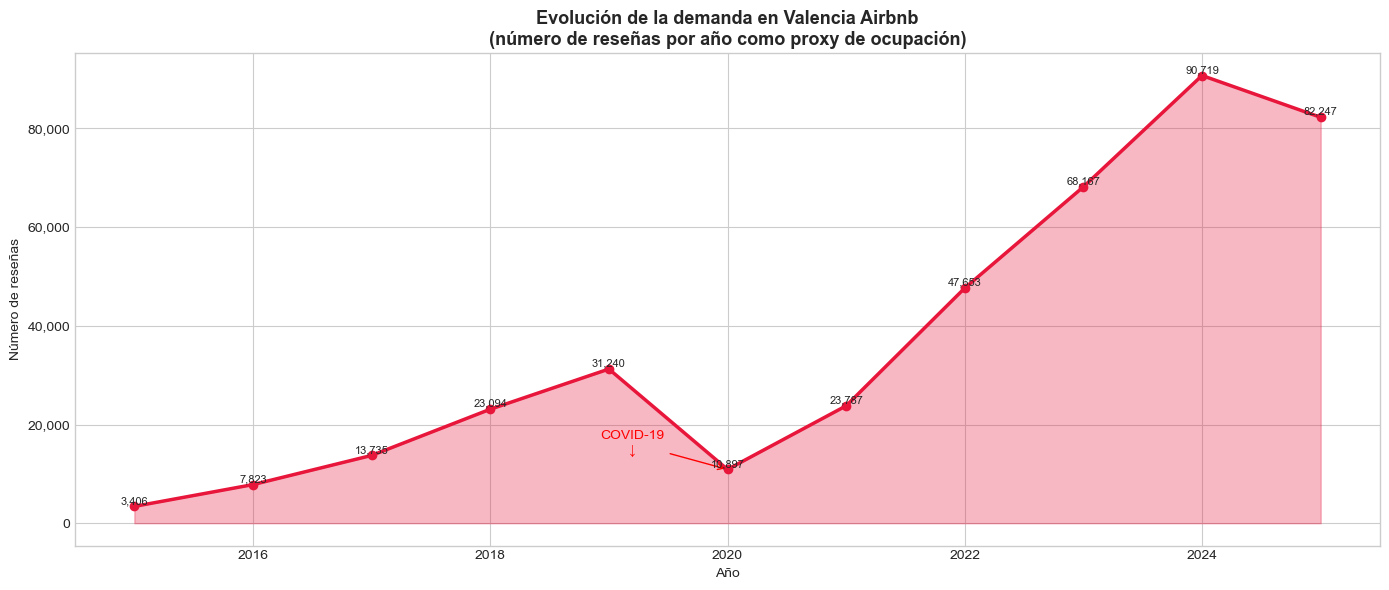

In [20]:
# ── Yearly review volume ──────────────────────────────────────
yearly = df_rev.groupby('year').size().reset_index(name='reviews')
yearly = yearly[yearly['year'] >= 2015]

fig, ax = plt.subplots(figsize=FIG_SIZE_WIDE)
ax.fill_between(yearly['year'], yearly['reviews'],
                alpha=0.3, color=COLOR_PRIMARY)
ax.plot(yearly['year'], yearly['reviews'],
        color=COLOR_PRIMARY, linewidth=2.5, marker='o', markersize=6)

# Annotate COVID impact
ax.annotate('COVID-19\n↓', xy=(2020, yearly[yearly['year']==2020]['reviews'].values[0]),
            xytext=(2019.2, yearly[yearly['year']==2020]['reviews'].values[0] * 1.3),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red', ha='center')

for _, row in yearly.iterrows():
    ax.text(row['year'], row['reviews'] + 500, f"{row['reviews']:,}",
            ha='center', fontsize=8)

ax.set_title('Evolución de la demanda en Valencia Airbnb\n'
             '(número de reseñas por año como proxy de ocupación)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Número de reseñas')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
save_fig('11_demand_trend.png')
plt.show()

---
## 7. Conclusiones del EDA

### ✅ Principales hallazgos

**Sobre el precio:**
- La distribución del precio es fuertemente sesgada a la derecha (mediana: 102€, media: 164€)
- No sigue distribución normal → se justifica el uso de tests no paramétricos
- La **capacidad (accommodates)** es el factor más correlacionado con el precio (ρ ≈ 0.60)
- El barrio y el tipo de habitación impactan significativamente el precio

**Sobre la rentabilidad:**
- **Precio alto ≠ rentabilidad alta** — la ocupación es igual o más importante que el precio
- Los barrios más rentables son: CIUTAT VELLA, L'EIXAMPLE, CAMINS AL GRAU
- La mediana de ingresos anuales es **5.544€/año**, con alta varianza entre barrios

**Sobre la demanda:**
- La demanda creció sostenidamente hasta 2019, cayó en COVID-2020, y se recuperó
- El mercado Valencia muestra recuperación post-pandemia robusta

### 🔧 Implicaciones para la limpieza y análisis posterior
- Usar **log(precio)** en análisis estadísticos
- Tests no paramétricos (Mann-Whitney, Kruskal-Wallis) para comparaciones de grupos
- Correlación de Spearman en lugar de Pearson

### ➡️ Próximos notebooks
- `02_statistical_analysis.ipynb` — Tests de hipótesis formales
- `03_seasonality.ipynb` — Estacionalidad con el calendar
- `04_host_analysis.ipynb` — Segmentación de hosts
- `05_investment_score.ipynb` — Score de inversión por barrio

In [22]:
# ── Save processed data for next notebooks ────────────────────
df.to_csv(PROCESSED_PATH / 'listings_clean.csv', index=False)
df_rev.to_csv(PROCESSED_PATH / 'reviews_clean.csv', index=False)
df_cal.to_csv(PROCESSED_PATH / 'calendar_clean.csv', index=False)

print('✅ Processed data saved:')
print(f'   listings_clean.csv  — {df.shape}')
print(f'   reviews_clean.csv   — {df_rev.shape}')
print(f'   calendar_clean.csv  — {df_cal.shape}')

✅ Processed data saved:
   listings_clean.csv  — (7780, 71)
   reviews_clean.csv   — (405009, 8)
   calendar_clean.csv  — (2863060, 10)
